In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, roc_auc_score
import os
import sys


In [8]:
#Get the directory of the current notebook (Notebooks/) and go up ONE level to the root (Telco/)
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

#Tell Python to add the root folder to its search path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Now build the absolute path to your dataset safely
DATA_PATH = os.path.join(PROJECT_ROOT, "data", "raw", "telco_customer_churn.csv")

In [9]:
#load data
df_1 = pd.read_csv(DATA_PATH) 

df_1.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

CustomerID with particular values for each customer certainly has no special information to offer our modelling, as is usual for ID columns. And why is TotalCharges that should have a 'float' dtype show as a 'string' object instead?

In [11]:
df_1 = df_1.drop(columns=['customerID'])

In [12]:
#investigate TotalCharges for possible blank values
empty_val_tc = df_1[df_1['TotalCharges'].str.strip()== '']

print(f"Found{len(empty_val_tc)}rows with empty values in TotalCharges") 
print(empty_val_tc[['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']])

Found11rows with empty values in TotalCharges
      tenure  Contract  MonthlyCharges TotalCharges
488        0  Two year           52.55             
753        0  Two year           20.25             
936        0  Two year           80.85             
1082       0  Two year           25.75             
1340       0  Two year           56.05             
3331       0  Two year           19.85             
3826       0  Two year           25.35             
4380       0  Two year           20.00             
5218       0  One year           19.70             
6670       0  Two year           73.35             
6754       0  Two year           61.90             


As suspected, there are empty values in TotalCharges which appear to be brand-new customers with no billing history yet, therefore their totalcharges remain blank. And blank values would make the column be summarised as a 'str' column.

In [13]:
#convert TotalCharges 'str' to 'numeric' by forcing empty values to NaN
df_1['TotalCharges'] = pd.to_numeric(df_1['TotalCharges'], errors = 'coerce')

#check missing values
print(df_1['TotalCharges'].isnull().sum())

11


In [14]:
#replace the NaN values with 0.0
df_1['TotalCharges'] = df_1['TotalCharges'].fillna(0.0)

#double-check the imputed column
print(df_1['TotalCharges'].dtype)
df_1[df_1['tenure'] == 0][['tenure', 'Contract', 'MonthlyCharges', 'TotalCharges']]

float64


,tenure,Contract,MonthlyCharges,TotalCharges
488,0,Two year,52.55,0.0
753,0,Two year,20.25,0.0
936,0,Two year,80.85,0.0
1082,0,Two year,25.75,0.0
1340,0,Two year,56.05,0.0
3331,0,Two year,19.85,0.0
3826,0,Two year,25.35,0.0
4380,0,Two year,20.00,0.0
5218,0,One year,19.70,0.0
6670,0,Two year,73.35,0.0


In [15]:
df_1.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [16]:
df_1['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

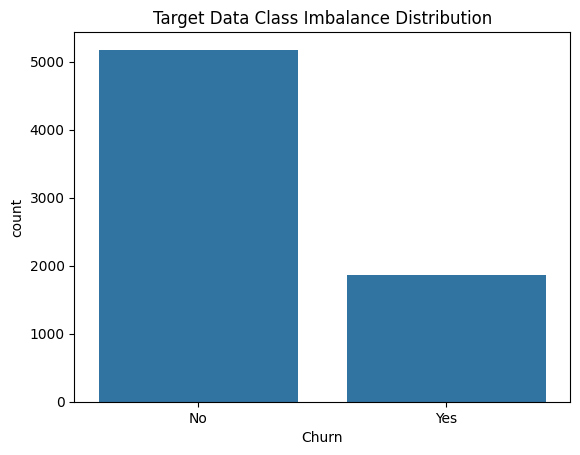

In [17]:
#visualise the target data distribution
sns.countplot(data=df_1, x = 'Churn')
plt.title('Target Data Class Imbalance Distribution')
plt.show()

There is the presence of data imbalance in our target column. We will make up for this imbalance with penalty terms when training our models. 

Check for multicollinearity.

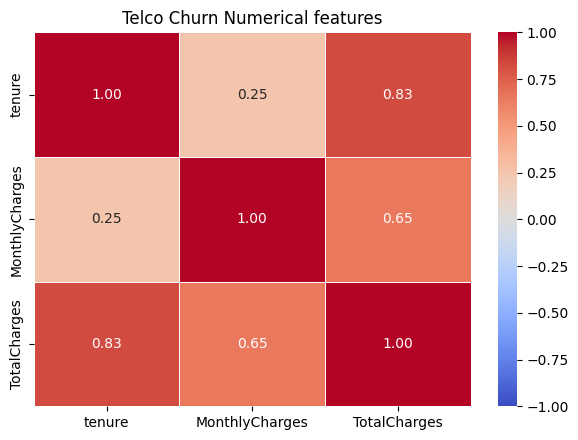

In [18]:
#isolate numerical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df_1[num_cols].corr()

#plot window size
plt.figure(figsize=(6, 4.5))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Telco Churn Numerical features')
plt.tight_layout()
plt.show()

This strong multicollinearity between the numerical variables would be a problem for our linear model, TotalCharges appears to be redundant.

In [19]:
df_2 = df_1.drop(columns=['TotalCharges'])
print(df_2.shape)
df_2.columns

(7043, 19)


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'Churn'],
      dtype='str')

In [20]:
#seperate target variable from features
X = df_2.drop(columns=['Churn'])
y = df_2['Churn']

#split data into 80\20 stratified splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = 42,
    stratify = y #keeps the 73/27 churn ratio identical in both splits
)

#check
print(f'Training set (X_train): {X_train.shape[0]} entries')
print(f'Testing set (X_test): {X_test.shape[0]} entries')
print(f'\nTraining Churn Ratio: \n {y_train.value_counts(normalize=True)}')

Training set (X_train): 5634 entries
Testing set (X_test): 1409 entries

Training Churn Ratio: 
 Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64


Move to Target Encoding for categorical columns 

In [21]:
#first ensure target variables are numeric (1 for Yes, 0 for No)
y_train = y_train.map({'Yes': 1, 'No': 0})
y_test = y_test.map({'Yes': 1, 'No': 0})

#identify numerical and categorical columns
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X_train.select_dtypes(include=['number']).columns.tolist()

#set up the pipeline with TargetEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', TargetEncoder(smooth="auto", cv=5, random_state=42), categorical_cols)],
    remainder='passthrough'
)

#fit and transform
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

#check shape of dataset
print("Encoded X_train shape:", X_train_processed.shape)

Encoded X_train shape: (5634, 18)


C:\Users\MY-PC\AppData\Local\Temp\ipykernel_12164\3137944892.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
c:\Users\MY-PC\Documents\Telco\.venv\Lib\site-packages\sklearn\preprocessing\_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Now that all the categorical columns are encoded, we can measure feature relevance with Mutual Information. This way, we might be able to remove irrelevant columns.

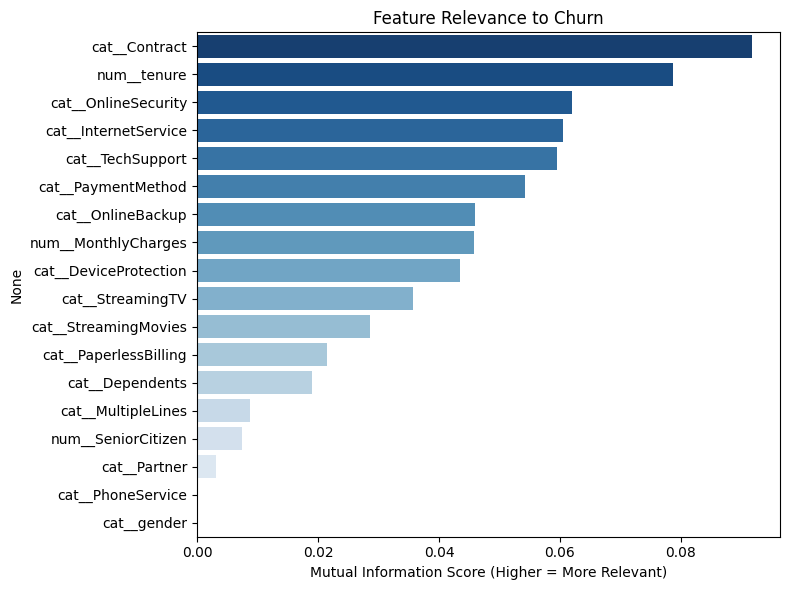

--- Ranked Feature Relevance ---
cat__Contract            0.091800
num__tenure              0.078738
cat__OnlineSecurity      0.062075
cat__InternetService     0.060504
cat__TechSupport         0.059447
cat__PaymentMethod       0.054253
cat__OnlineBackup        0.046023
num__MonthlyCharges      0.045876
cat__DeviceProtection    0.043533
cat__StreamingTV         0.035642
cat__StreamingMovies     0.028521
cat__PaperlessBilling    0.021493
cat__Dependents          0.019062
cat__MultipleLines       0.008691
num__SeniorCitizen       0.007372
cat__Partner             0.003116
cat__PhoneService        0.000149
cat__gender              0.000000
dtype: float64


In [22]:
#calculate Mutual Information scores
mi_scores = mutual_info_classif(X_train_processed, y_train, random_state=42)

#generate the features names from previously fitted preprocessor
encoded_feature_names = preprocessor.get_feature_names_out()

#pair calculated scores with column names extracted
mi_ranked = pd.Series(mi_scores, index=encoded_feature_names).sort_values(ascending=False)

#visualise the ranked features
plt.figure(figsize=(8, 6))
sns.barplot(x=mi_ranked.values, y=mi_ranked.index, hue=mi_ranked.index, palette='Blues_r', legend=False)
plt.title('Feature Relevance to Churn')
plt.xlabel('Mutual Information Score (Higher = More Relevant)')
plt.tight_layout()
plt.show()

# Print the exact scores to audit
print("--- Ranked Feature Relevance ---")
print(mi_ranked)

In [23]:
#define relevance threshold
threshold = 0.007

#identify column names above the threshold
relevant_columns = mi_ranked[mi_ranked > threshold].index.tolist()
dropped_columns = mi_ranked[mi_ranked <= threshold].index.tolist()

print(f"Dropping {len(dropped_columns)} low-relevance features: {dropped_columns}")
print(f"Keeping {len(relevant_columns)} features for modeling.")

#find the indices of the relevant columns to slice our NumPy arrays
relevant_indices = [list(encoded_feature_names).index(col) for col in relevant_columns]

#filter down final training and testing data matrices
X_train_final = X_train_processed[:, relevant_indices]
X_test_final = X_test_processed[:, relevant_indices]

Dropping 3 low-relevance features: ['cat__Partner', 'cat__PhoneService', 'cat__gender']
Keeping 15 features for modeling.


In [24]:
#verify final shape of train and test data
print("Final X_train shape:", X_train_final.shape)
print("Final X_test shape:", X_test_final.shape)

Final X_train shape: (5634, 15)
Final X_test shape: (1409, 15)


Model Training

For the Logistic Regression model, we will add a penalty term to make up for our class imbalance in the target variable. This will mathematically penalise mistakes on the churned class more heavily.

In [ ]:
#initialize the model
log_reg = LogisticRegression(
    class_weight='balanced', #penalty for imbalanced classes
    random_state=42, 
    max_iter=1000)

#execute 5-fold cross-validation with 'roc_auc' as the scoring metric
cv_scores = cross_val_score(log_reg, X_train_final, y_train, cv=5, scoring='roc_auc')

print("--- Cross-Validation Performance ---")
print(f"Mean Training ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})\n")

#train model on the entire training data
log_reg.fit(X_train_final, y_train)

#make predictions
y_pred = log_reg.predict(X_test_final)
y_pred_proba = log_reg.predict_proba(X_test_final)[:, 1]

#output the results
print("--- Final Test Set Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

--- Cross-Validation Performance ---
Mean Training ROC-AUC: 0.8418 (+/- 0.0290)

--- Final Test Set Classification Report ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

Final Test ROC-AUC Score: 0.8371


In [26]:
#get the weights from the trained model
#log_reg.coef_[0] gives the 1D array of weights corresponding to X_train_final
coefficients = log_reg.coef_[0]

#pair the weights with the exact column names created during the mutual information step
coef_df = pd.DataFrame({
    'Feature': relevant_columns,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False)

#print exact weights 
print("--- Exact Coefficient Weights ---")
print(coef_df.to_string(index=False))

--- Exact Coefficient Weights ---
              Feature  Coefficient
        cat__Contract     2.680337
cat__PaperlessBilling     1.795441
 cat__InternetService     1.782592
  cat__OnlineSecurity     1.699026
   cat__PaymentMethod     1.444012
     cat__TechSupport     1.411925
      cat__Dependents     1.214488
    cat__OnlineBackup     0.727814
  num__MonthlyCharges     0.387877
   cat__MultipleLines     0.135313
   num__SeniorCitizen     0.081577
cat__DeviceProtection     0.005182
          num__tenure    -0.711786
     cat__StreamingTV    -1.130266
 cat__StreamingMovies    -1.580603


The above results from our trained Log_reg model can help us pinpoint traits of customers who are more likely to churn.

Decision Trees

In [27]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_curve

#initialise decision tree model, max_depth=5 to prevent overfitting on target encoded predictors
dec_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

#execute 5-Fold cross-validation with roc_auc as scoring metric
dt_cv_scores = cross_val_score(dec_tree, X_train_final, y_train, cv=5, scoring='roc_auc')

print("--- Decision Tree 5-Fold CV (ROC-AUC) ---")
print(f"Scores: {dt_cv_scores}")
print(f"Mean ROC-AUC: {np.mean(dt_cv_scores):.4f} (+/- {np.std(dt_cv_scores):.4f})\n")

#model training
dec_tree.fit(X_train_final, y_train)

#threshold optimization on train set
#get probabilities for the positive class (churn)
dt_train_probs = dec_tree.predict_proba(X_train_final)[:, 1]
dt_fpr, dt_tpr, dt_thresholds = roc_curve(y_train, dt_train_probs)

#maximize geometric mean to balance between true positives and true negatives
dt_gmeans = np.sqrt(dt_tpr * (1 - dt_fpr))
dt_ix = np.argmax(dt_gmeans)
dt_best_threshold = dt_thresholds[dt_ix]

print(f"Optimized Decision Tree Threshold: {dt_best_threshold:.4f}")

#predict
dt_test_probs = dec_tree.predict_proba(X_test_final)[:, 1]
dt_custom_preds = (dt_test_probs >= dt_best_threshold).astype(int)

print(f"\n--- Decision Tree Classification Report (Threshold: {dt_best_threshold:.4f}) ---")
print(classification_report(y_test, dt_custom_preds))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test, dt_test_probs):.4f}")

--- Decision Tree 5-Fold CV (ROC-AUC) ---
Scores: [0.83958808 0.81984433 0.82033509 0.8344421  0.80396364]
Mean ROC-AUC: 0.8236 (+/- 0.0125)

Optimized Decision Tree Threshold: 0.2744

--- Decision Tree Classification Report (Threshold: 0.2744) ---
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.77      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.79      0.73      0.75      1409

Final Test ROC-AUC Score: 0.8276


AdaBoost Classifier

In [28]:
from sklearn.ensemble import AdaBoostClassifier

#initialization
ada_model = AdaBoostClassifier(n_estimators=50, learning_rate=1.0, random_state=42)

#execute 5-Fold Cross-Validation with roc_auc
ada_cv_scores = cross_val_score(ada_model, X_train_final, y_train, cv=5, scoring='roc_auc')

print("--- AdaBoost 5-Fold CV (ROC-AUC) ---")
print(f"Scores: {ada_cv_scores}")
print(f"Mean ROC-AUC: {np.mean(ada_cv_scores):.4f} (+/- {np.std(ada_cv_scores):.4f})\n")

#train model on the entire training data
ada_model.fit(X_train_final, y_train)

#Threshold Optimization on train Set
# Get probabilities for the positive class (churn)
ada_train_probs = ada_model.predict_proba(X_train_final)[:, 1]
ada_fpr, ada_tpr, ada_thresholds = roc_curve(y_train, ada_train_probs)

#maximize Geometric Mean to balance between True Positives and True Negatives
ada_gmeans = np.sqrt(ada_tpr * (1 - ada_fpr))
ada_ix = np.argmax(ada_gmeans)
ada_best_threshold = ada_thresholds[ada_ix]

print(f"Optimized AdaBoost Threshold: {ada_best_threshold:.4f}")

#prediction and print classification report
ada_test_probs = ada_model.predict_proba(X_test_final)[:, 1]
ada_custom_preds = (ada_test_probs >= ada_best_threshold).astype(int)

print(f"\n--- AdaBoost Classification Report (Threshold: {ada_best_threshold:.4f}) ---")
print(classification_report(y_test, ada_custom_preds))
print(f"Final Test ROC-AUC Score: {roc_auc_score(y_test, ada_test_probs):.4f}")

--- AdaBoost 5-Fold CV (ROC-AUC) ---
Scores: [0.86358514 0.84509961 0.85281252 0.82935267 0.80985389]
Mean ROC-AUC: 0.8401 (+/- 0.0188)

Optimized AdaBoost Threshold: 0.4318

--- AdaBoost Classification Report (Threshold: 0.4318) ---
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

Final Test ROC-AUC Score: 0.8408


Suprisingly, our linear and Boosting models are at a tie with a roc_auc score of 0.84. 